<a href="https://colab.research.google.com/github/shetashreya/Quantum_Neural_Network_Image_Classification/blob/main/Quantum_Neural_Networks_for_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q pennylane torch torchvision matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 108.5 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import pennylane as qml

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
# Number of qubits
NUM_QUBITS = 4

# Number of MNIST classes
NUM_CLASSES = 10

# Training parameters
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.001

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [6]:
transform = transforms.Compose([
    transforms.Resize((4, 4)),
    transforms.ToTensor()
])

# Training dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Testing dataset
test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]

Training samples: 60000
Testing samples: 10000


In [7]:
train_dataset = torch.utils.data.Subset(
    train_dataset,
    range(5000)
)

test_dataset = torch.utils.data.Subset(
    test_dataset,
    range(1000)
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 5000
Testing samples: 1000


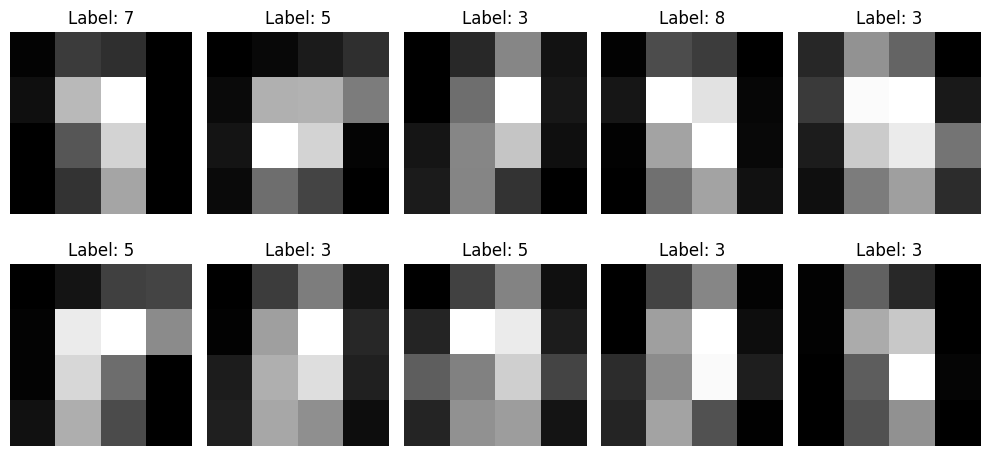

In [8]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)

print("Quantum device created")
print("Number of qubits:", NUM_QUBITS)

Quantum device created
Number of qubits: 4


In [10]:
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # --------------------------------
    # Encode classical data
    # --------------------------------
    for i in range(NUM_QUBITS):
        qml.RY(
            inputs[i],
            wires=i
        )

    # --------------------------------
    # Variational quantum layers
    # --------------------------------
    for layer in range(2):

        # Trainable rotations
        for i in range(NUM_QUBITS):

            qml.RY(
                weights[layer, i, 0],
                wires=i
            )

            qml.RZ(
                weights[layer, i, 1],
                wires=i
            )

        # Entanglement
        for i in range(NUM_QUBITS - 1):

            qml.CNOT(
                wires=[i, i + 1]
            )

        # Close the entanglement ring
        qml.CNOT(
            wires=[NUM_QUBITS - 1, 0]
        )

    # --------------------------------
    # Measure qubits
    # --------------------------------
    return [
        qml.expval(qml.PauliZ(i))
        for i in range(NUM_QUBITS)
    ]

In [11]:
sample_inputs = torch.tensor(
    [0.1, 0.2, 0.3, 0.4],
    requires_grad=True
)

sample_weights = torch.randn(
    2,
    NUM_QUBITS,
    2
)

print(
    qml.draw(quantum_circuit)(
        sample_inputs,
        sample_weights
    )
)

0: ──RY(0.10)──RY(-1.87)──RZ(1.52)──╭●───────╭X──RY(-0.32)──RZ(-1.82)─╭●───────╭X─┤  <Z>
1: ──RY(0.20)──RY(-0.12)──RZ(0.16)──╰X─╭●────│───RY(0.20)───RZ(-0.28)─╰X─╭●────│──┤  <Z>
2: ──RY(0.30)──RY(-0.05)──RZ(0.11)─────╰X─╭●─│───RY(0.53)───RZ(-2.10)────╰X─╭●─│──┤  <Z>
3: ──RY(0.40)──RY(0.16)───RZ(-0.48)───────╰X─╰●──RY(-0.76)──RZ(-0.27)───────╰X─╰●─┤  <Z>


In [12]:
weight_shapes = {
    "weights": (2, NUM_QUBITS, 2)
}

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)

print("Quantum layer created successfully.")

Quantum layer created successfully.


In [13]:
class QuantumNeuralNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        # Flatten 4x4 image
        self.flatten = nn.Flatten()

        # Classical feature extraction
        self.classical_layer = nn.Sequential(

            nn.Linear(16, 8),

            nn.ReLU(),

            nn.Linear(8, NUM_QUBITS)
        )

        # Quantum layer
        self.quantum_layer = quantum_layer

        # Final classical classifier
        self.output_layer = nn.Linear(
            NUM_QUBITS,
            NUM_CLASSES
        )

    def forward(self, x):

        # 4x4 image -> 16 values
        x = self.flatten(x)

        # Classical neural network
        x = self.classical_layer(x)

        # Convert values to rotation angles
        x = torch.tanh(x) * torch.pi

        # Quantum processing
        quantum_outputs = []

        for sample in x:

            q_output = self.quantum_layer(
                sample
            )

            quantum_outputs.append(q_output)

        x = torch.stack(
            quantum_outputs
        )

        # Final classification
        x = self.output_layer(x)

        return x

In [14]:
model = QuantumNeuralNetwork().to(device)

print(model)

QuantumNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classical_layer): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
  (quantum_layer): <Quantum Torch Layer: func=quantum_circuit>
  (output_layer): Linear(in_features=4, out_features=10, bias=True)
)


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [17]:
device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [18]:
model = QuantumNeuralNetwork().to(device)

print("Model device:", next(model.parameters()).device)

Model device: cpu


In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer ready")

Optimizer ready


In [23]:
print("Starting training...\n")

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(
            outputs.data,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses.append(
        epoch_loss
    )

    train_accuracies.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Starting training...

Epoch [1/5] Loss: 1.7637 | Accuracy: 35.30%
Epoch [2/5] Loss: 1.7032 | Accuracy: 37.56%
Epoch [3/5] Loss: 1.6511 | Accuracy: 38.78%
Epoch [4/5] Loss: 1.6087 | Accuracy: 39.48%
Epoch [5/5] Loss: 1.5794 | Accuracy: 39.74%


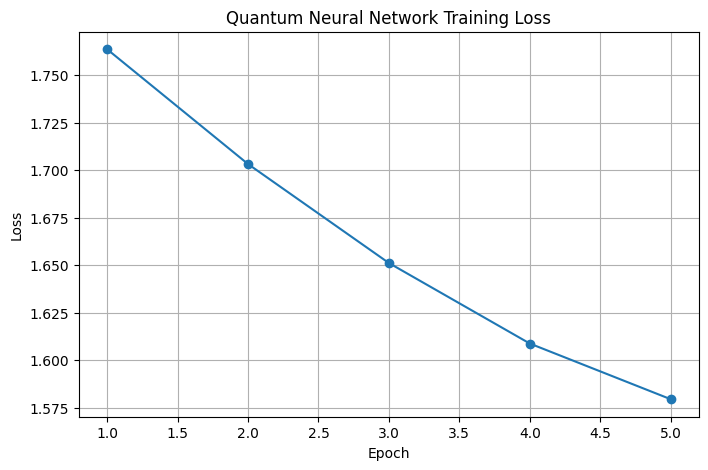

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Quantum Neural Network Training Loss"
)

plt.grid()

plt.show()

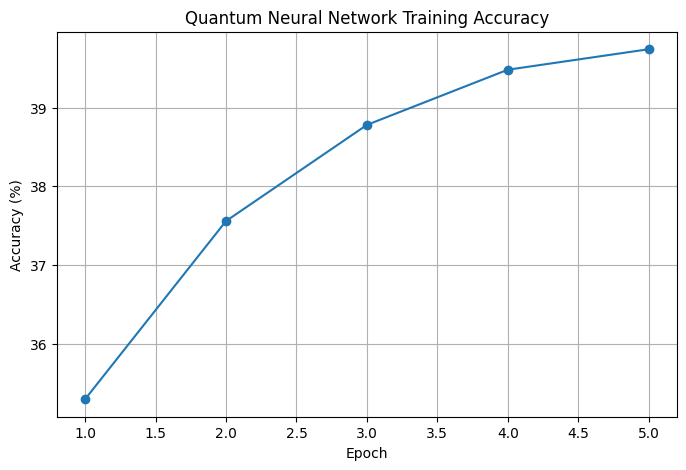

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Quantum Neural Network Training Accuracy"
)

plt.grid()

plt.show()

In [27]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        # Store predictions and actual labels
        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100 * correct / total

print("==============================")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print("==============================")

Test Accuracy: 36.90%


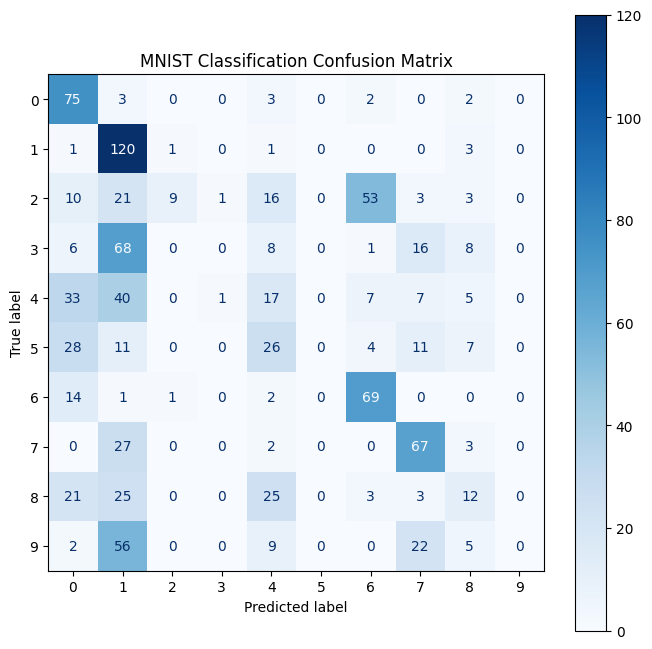

In [28]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

fig, ax = plt.subplots(
    figsize=(8, 8)
)

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title(
    "MNIST Classification Confusion Matrix"
)

plt.show()

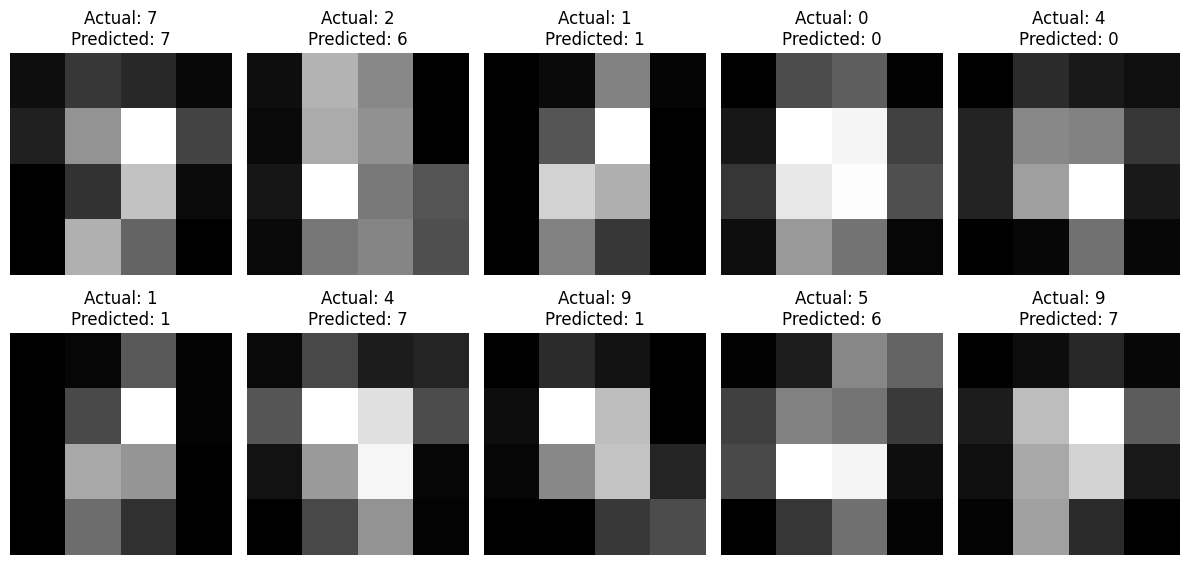

In [29]:
images, labels = next(iter(test_loader))

images_device = images.to(device)

model.eval()

with torch.no_grad():

    outputs = model(
        images_device
    )

    predictions = torch.argmax(
        outputs,
        dim=1
    ).cpu()

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {labels[i].item()}\n"
        f"Predicted: {predictions[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()